# The concurrency envelope: GPU flood beside CPU loads

**What this notebook shows.** The optimized flood kernel exists so the
Raspberry Pi 5's idle GPU can run a real-time simulation while the CPU
does other work; the two share one LPDDR memory bus, so the interference
must be measured. This notebook derives, from committed raw logs:

1. steady-state throughput of each flood kernel alone and beside LLM
   decode (the paper's Table IV);
2. the CPU-only counterfactual under the same protocol (Table V);
3. GPU and CPU retention under generic (non-LLM) CPU loads;
4. the device-visibility decode A/B.

**Protocol.** Concurrent and decode-alone phases are measured only after
a cooldown and a fixed eight-repetition decode soak. The soak is not gated
on the throttle bit, and the conditions did not reach the same thermal state.
A flood run counts only if it starts and finishes inside the window. Generic-load
pairings use continuous sim-mode GPU probes over cool-start 60 s windows.
The windowing rule shared with the paper lives in
`../pi/flood/analyze_conc_bench.py`; this notebook reuses it and
re-derives key numbers independently with `analysis_utils.py`.

**Data provenance.** All inputs are unmodified logs under
`../docs/paper/artifacts/`, produced on the board:

| Directory | Produced by | Date |
|---|---|---|
| `conc_steady_2026-08-10/` | `pi/flood/conc_steady_bench.sh` | 2026-08-10 |
| `cpu_steady_2026-08-10/` | `pi/flood/cpu_steady_bench.sh` | 2026-08-10 |
| `genload2_2026-08-10/` | `pi/flood/genload2_bench.sh` | 2026-08-10 |
| `ab_vkvisible_2026-08-10/` | `run_script.sh` (archived in the directory) | 2026-08-10 |
| `conc_bench2/`, `cpu_flood_bench/`, `cpu_flood_bench2/` | earlier short-window (thermal-transient) campaigns, kept for comparison | 2026-07-12 |

This notebook supports Section VII, Tables IV and V, of
`../docs/paper/paper.pdf`. It runs offline.

In [1]:
import statistics
import subprocess
import sys
from pathlib import Path

import analysis_utils as au

ART = Path("../docs/paper/artifacts")


def analyze(d, steps=4000):
    out = subprocess.run(
        [sys.executable, "../pi/flood/analyze_conc_bench.py", str(d), str(steps)],
        capture_output=True,
        text=True,
    )
    print(out.stdout)


print("=== steady-state campaign (Table IV) ===")
analyze(ART / "conc_steady_2026-08-10")
print("=== earlier transient-window campaign, for comparison ===")
analyze(ART / "conc_bench2")

=== steady-state campaign (Table IV) ===
flood opt alone                              2128.0 ±   1.7 steps/s  (n=3)
flood orig alone                             1351.4 ±   0.5 steps/s  (n=3)
flood opt under CPU decode                    883.4 ±  47.1 steps/s  (n=28)
flood orig under CPU decode                   401.8 ±   8.3 steps/s  (n=12)
llama alone                                    11.4 ±   0.0 t/s     (n=5)
llama alone soak                               11.4 ±   0.1 t/s     (n=5)
llama vs opt                                    9.6 ±   0.2 t/s     (n=5)
llama vs opt soak                              10.2 ±   0.2 t/s     (n=5)
llama vs orig                                   9.6 ±   0.2 t/s     (n=5)
llama vs orig soak                              9.9 ±   0.2 t/s     (n=5)

thermal validity (max temp / samples with throttle ACTIVE):
  thermal_end.log                    max  74.7 C  TAINTED (1 throttled samples)
  thermal_llama_alone.log            max  73.0 C  TAINTED (5 throttled s

The steady campaign is the paper's Table IV: the GPU keeps 42% of its
solo rate beside decode (883.4 / 2,128.0), decode keeps 84% (9.6 / 11.4),
and the optimized kernel's concurrent advantage is 883.4 / 401.8 = 2.20x.
The transient campaign reads 711.9 concurrent with decode at 10.3. The
thermal audit above also shows the optimized-kernel rate still drifting
upward within the steady window, so the reported mean is conservative.

## 1b. The transient campaign, aligned

The two campaigns look 19% apart until their windows are aligned on time
since decode began. The transient campaign had no soak: its five counted
completions began 4 to 32 seconds after the flood loop and decode
launched together, where the firmware's soft temperature limit (near
73 C; first flicker at +18 s there, +31 s here) had not yet settled into
continuous capping. The steady campaign's flood log covers those same
seconds during its soak. The same segment gives the same numbers:

In [2]:
import re


def completions(path, steps=4000):
    text = Path(path).read_text()
    t0 = float(re.search(r"t=([0-9.]+)", text).group(1))
    return [
        (float(m.group(1)) - t0, steps / float(m.group(2)))
        for m in re.finditer(r"t=([0-9.]+)\n(?:.*?\n)*?.*?time=([0-9.]+)s", text)
    ]


segment = {}
for name, d in (("transient", "conc_bench2"), ("steady", "conc_steady_2026-08-10")):
    runs = completions(ART / d / "flood_opt_conc.log")
    segment[name] = [r for t, r in runs if 4 <= t <= 32]
    print(f"{name:9s} completions (s after loop start : steps/s)")
    print("   ", "  ".join(f"+{t:.0f}:{r:.0f}" for t, r in runs[:11]))
    print("    first-half-minute segment:", au.fmt(segment[name]), "steps/s\n")

print("decode beside the optimized kernel (llama-bench tg64):")
print("  transient window ", au.tps(ART / "conc_bench2/llama_vs_opt.log"), "t/s")
print("  steady, soak     ", au.tps(ART / "conc_steady_2026-08-10/llama_vs_opt_soak.log"), "t/s")
print("  steady, measured ", au.tps(ART / "conc_steady_2026-08-10/llama_vs_opt.log"), "t/s")

assert len(segment["transient"]) == len(segment["steady"]) == 5
gap = abs(statistics.mean(segment["transient"]) - statistics.mean(segment["steady"]))
assert gap < statistics.stdev(segment["transient"]), gap

transient completions (s after loop start : steps/s)
    +0:2127  +2:2036  +4:654  +10:657  +17:675  +23:742  +28:832
    first-half-minute segment:    711.9 ±   76.1  (n=5) steps/s

steady    completions (s after loop start : steps/s)
    +0:2129  +2:1026  +6:647  +12:653  +19:625  +25:677  +31:715  +37:702  +43:782  +48:779  +53:1134
    first-half-minute segment:    663.3 ±   34.4  (n=5) steps/s

decode beside the optimized kernel (llama-bench tg64):
  transient window  10.32 ± 0.24 t/s
  steady, soak      10.21 ± 0.23 t/s
  steady, measured  9.58 ± 0.24 t/s


Aligned on the same seconds, the campaigns agree: the transient window
sat where the steady campaign's soak sat, decode still ran near 10.3 t/s,
and the flood rate had not yet risen. Once the cap settles, decode slows
to 9.6 and the flood climbs to the Table IV rate. The 711.9-vs-883.4
difference is window position on one settling curve; Section VII of the
paper states it that way, and Section VIII notes the settled regime was
measured once.

## 2. The CPU-only counterfactual (Table V)

In [3]:
C = ART / "cpu_steady_2026-08-10"
print("Table V (steady-state counterfactual)")
for t in (1, 2, 4):
    print(
        f"  CPU flood {t}t alone      ", au.fmt(au.sps(C / f"flood_cpu{t}t_alone.log")), "steps/s"
    )
print("  decode 3t alone (soaked)", au.tps(C / "llama_t3_alone.log"), "t/s")
print("  partitioned flood       ", au.fmt(au.windowed(C / "flood_cpu1part_conc.log")), "steps/s")
print("  partitioned decode      ", au.tps(C / "llama_vs_cpu1part.log"), "t/s")
print("  oversubscribed flood    ", au.fmt(au.windowed(C / "flood_cpu4over_conc.log")), "steps/s")
print("  oversubscribed decode   ", au.tps(C / "llama_vs_cpu4over.log"), "t/s")

print("\npartitioned replication across the three campaigns:")
for camp in ("cpu_flood_bench", "cpu_flood_bench2", "cpu_steady_2026-08-10"):
    d = ART / camp
    print(
        f"  {camp:22s}",
        au.fmt(au.windowed(d / "flood_cpu1part_conc.log")),
        "steps/s, decode",
        au.tps(d / "llama_vs_cpu1part.log"),
        "t/s",
    )

Table V (steady-state counterfactual)
  CPU flood 1t alone          992.5 ±    0.6  (n=3) steps/s
  CPU flood 2t alone         1980.5 ±    2.5  (n=3) steps/s
  CPU flood 4t alone         3852.4 ±   15.4  (n=3) steps/s
  decode 3t alone (soaked) 11.90 ± 0.01 t/s
  partitioned flood           678.8 ±   10.6  (n=25) steps/s
  partitioned decode       8.41 ± 0.05 t/s
  oversubscribed flood        857.1 ±  181.0  (n=89) steps/s
  oversubscribed decode    2.97 ± 0.33 t/s

partitioned replication across the three campaigns:
  cpu_flood_bench           678.4 ±   63.3  (n=7) steps/s, decode 6.95 ± 0.13 t/s
  cpu_flood_bench2          680.6 ±   22.9  (n=6) steps/s, decode 8.38 ± 0.03 t/s
  cpu_steady_2026-08-10     678.8 ±   10.6  (n=25) steps/s, decode 8.41 ± 0.05 t/s


The GPU split (883.4 ± 47.1 steps/s beside 9.6 ± 0.2 t/s) beats the
partitioned CPU-only best on both axes: +30% simulation, +14% decode.
The partitioned flood rate replicates across all three campaigns that
measured it. The first campaign's lower decode traces to its
visible-device configuration (its llama logs open with `ggml_vulkan:
Found 1 Vulkan devices`), predating the device-visibility fix of
section 4.

## 3. Generic CPU loads

Both sides of every pairing, from `genload2_2026-08-10/`.

In [4]:
G = ART / "genload2_2026-08-10"
ga = au.windowed(G / "gpu_alone_gpu.log", "window_start", "window_end")
go = au.windowed(G / "openssl_pair_gpu.log", "window_start", "window_end")
gc = au.windowed(G / "cpuflood_pair_gpu.log", "window_start", "window_end")
ca = au.sps(G / "cpuflood_alone.log")
cc = au.windowed(G / "cpuflood_pair_cpu.log", "window_start", "window_end")
base = statistics.mean(ga)
print("GPU alone                 ", au.fmt(ga))
print(
    "GPU + openssl 4t          ", au.fmt(go), f" GPU keeps {statistics.mean(go) / base * 100:5.1f}%"
)
print(
    "GPU + cpuflood 4t         ", au.fmt(gc), f" GPU keeps {statistics.mean(gc) / base * 100:5.1f}%"
)
print("cpuflood alone            ", au.fmt(ca))
print(
    "cpuflood beside GPU       ",
    au.fmt(cc),
    f" load keeps {statistics.mean(cc) / statistics.mean(ca) * 100:5.1f}%",
)

ossl = {}
for tag, f in (("alone", "openssl_alone.log"), ("paired", "openssl_pair_cpu.log")):
    ossl[tag] = float(re.findall(r"sha256\s+(.*)", (G / f).read_text())[-1].split()[-1].rstrip("k"))
print(
    f"openssl 16KB-block alone {ossl['alone'] / 1e6:.2f} GB/s, beside GPU {ossl['paired'] / 1e6:.2f} GB/s"
    f" (load keeps {ossl['paired'] / ossl['alone'] * 100:.1f}%)"
)

GPU alone                    2126.0 ±    1.9  (n=30)
GPU + openssl 4t             2106.3 ±    7.2  (n=149)  GPU keeps  99.1%
GPU + cpuflood 4t            1953.4 ±   26.8  (n=27)  GPU keeps  91.9%
cpuflood alone               3831.2 ±   69.3  (n=57)
cpuflood beside GPU          2862.4 ±  291.8  (n=42)  load keeps  74.7%
openssl 16KB-block alone 5.97 GB/s, beside GPU 5.25 GB/s (load keeps 87.8%)


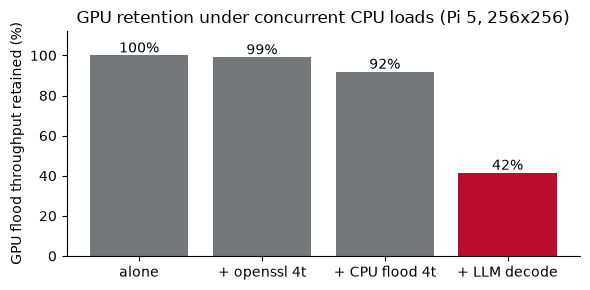

In [5]:
import matplotlib.pyplot as plt

labels = ["alone", "+ openssl 4t", "+ CPU flood 4t", "+ LLM decode"]
retained = [
    100,
    statistics.mean(go) / base * 100,
    statistics.mean(gc) / base * 100,
    883.4 / 2128.0 * 100,
]
fig, ax = plt.subplots(figsize=(6, 3))
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.bar(labels, retained, color=["#75787b"] * 3 + ["#ba0c2f"])
ax.set_ylabel("GPU flood throughput retained (%)")
ax.set_title("GPU retention under concurrent CPU loads (Pi 5, 256x256)")
for i, v in enumerate(retained):
    ax.text(i, v + 1.5, f"{v:.0f}%", ha="center")
ax.set_ylim(0, 112)
plt.tight_layout()
plt.savefig("gpu_retention.png", dpi=400)
plt.show()

The GPU is the steadier side of every pairing except decode, which
streams model weights from DRAM every token: interference tracks the CPU
load's memory traffic.

## 4. The device-visibility A/B

With any Vulkan device visible, llama.cpp places CPU-resident model
weights in host-pinned, write-combined GPU memory even at `-ngl 0`,
which is slow for the CPU reads that dominate decode. Both runs from
cool starts, invocation archived beside the logs:

In [6]:
A = ART / "ab_vkvisible_2026-08-10"
for tag in ("visible", "hidden"):
    line = [ln for ln in (A / f"{tag}.log").read_text().splitlines() if "tg64" in ln][0]
    print(f"{tag:8s}", line.split("|")[-2].strip(), "t/s")
vis, hid = (
    float(
        [ln for ln in (A / f"{t}.log").read_text().splitlines() if "tg64" in ln][0]
        .split("|")[-2]
        .split("\u00b1")[0]
    )
    for t in ("visible", "hidden")
)
print(f"\ngain from hiding the device: {hid / vis * 100 - 100:.1f}%")

visible  9.68 ± 0.00 t/s
hidden   11.59 ± 0.00 t/s

gain from hiding the device: 19.7%


## Rerunning live

```
# on the Pi
OUT=/tmp/conc_steady bash pi/flood/conc_steady_bench.sh
OUT=/tmp/cpu_steady bash pi/flood/cpu_steady_bench.sh
OUT=/tmp/genload2 bash pi/flood/genload2_bench.sh
OUT=/tmp/ab bash pi/flood/ab_vkvisible_bench.sh
python3 pi/flood/analyze_conc_bench.py /tmp/conc_steady 4000
```

## Environment

In [7]:
au.environment()

python 3.14.3
matplotlib 3.11.1


nbformat 5.11.0
